In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("events.csv")

print("Dataset Shape:", df.shape)
display(df.head())
df.info()

Dataset Shape: (2756101, 5)


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [ ]:
print(df['event'].value_counts())

print("\nPercentage Distribution:")
print(df['event'].value_counts(normalize=True) * 100)

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

Percentage Distribution:
event
view           96.669607
addtocart       2.515583
transaction     0.814810
Name: proportion, dtype: float64


In [ ]:
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()

display(df.head())

,timestamp,visitorid,event,itemid,transactionid,datetime,date,hour,day_of_week
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,5,Tuesday
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,5,Tuesday
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,5,Tuesday
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,5,Tuesday
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,5,Tuesday


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Visitors:")
print(df['visitorid'].nunique())

print("\nUnique Products:")
print(df['itemid'].nunique())

print("\nDate Range:")
print(df['datetime'].min())
print(df['datetime'].max())

Missing Values:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
datetime               0
date                   0
hour                   0
day_of_week            0
dtype: int64

Duplicate Rows:
460

Unique Visitors:
1407580

Unique Products:
235061

Date Range:
2015-05-03 03:00:04.384000
2015-09-18 02:59:47.788000


Funnel Analysis

In [ ]:
# Number of unique users at each stage

views = df[df['event'] == 'view']['visitorid'].nunique()

add_to_cart = df[df['event'] == 'addtocart']['visitorid'].nunique()

transactions = df[df['event'] == 'transaction']['visitorid'].nunique()

funnel = pd.DataFrame({
    'Stage': ['View', 'Add to Cart', 'Transaction'],
    'Users': [views, add_to_cart, transactions]
})

funnel

,Stage,Users
0,View,1404179
1,Add to Cart,37722
2,Transaction,11719


In [ ]:
view_to_cart = (add_to_cart / views) * 100

cart_to_transaction = (transactions / add_to_cart) * 100

overall_conversion = (transactions / views) * 100

print(f"View to Cart Conversion Rate: {view_to_cart:.2f}%")

print(f"Cart to Transaction Conversion Rate: {cart_to_transaction:.2f}%")

print(f"Overall Conversion Rate: {overall_conversion:.2f}%")

View to Cart Conversion Rate: 2.69%
Cart to Transaction Conversion Rate: 31.07%
Overall Conversion Rate: 0.83%


In [ ]:
view_dropoff = 100 - view_to_cart

cart_dropoff = 100 - cart_to_transaction

print(f"Drop-off from View to Cart: {view_dropoff:.2f}%")

print(f"Drop-off from Cart to Transaction: {cart_dropoff:.2f}%")

Drop-off from View to Cart: 97.31%
Drop-off from Cart to Transaction: 68.93%


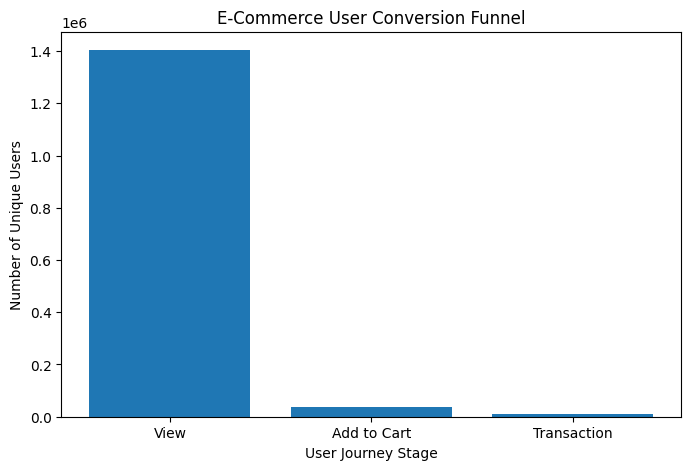

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(funnel['Stage'], funnel['Users'])

plt.title('E-Commerce User Conversion Funnel')

plt.xlabel('User Journey Stage')

plt.ylabel('Number of Unique Users')

plt.show()

Cart Abandonment Analysis


In [ ]:
# Users who added at least one product to cart
cart_users = set(
    df[df['event'] == 'addtocart']['visitorid'].unique()
)

# Users who made at least one transaction
purchase_users = set(
    df[df['event'] == 'transaction']['visitorid'].unique()
)

# Users who added to cart but never purchased
abandoned_cart_users = cart_users - purchase_users

print("Users who added to cart:", len(cart_users))
print("Users who made a purchase:", len(purchase_users))
print("Users who abandoned the cart:", len(abandoned_cart_users))

Users who added to cart: 37722
Users who made a purchase: 11719
Users who abandoned the cart: 27146


In [ ]:
cart_abandonment_rate = (
    len(abandoned_cart_users) / len(cart_users)
) * 100

print(f"Cart Abandonment Rate: {cart_abandonment_rate:.2f}%")

Cart Abandonment Rate: 71.96%


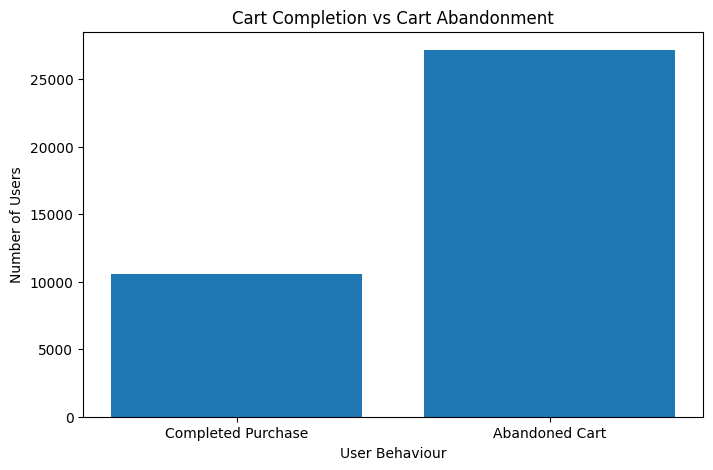

In [ ]:
cart_analysis = pd.DataFrame({
    'User Group': [
        'Completed Purchase',
        'Abandoned Cart'
    ],
    'Users': [
        len(purchase_users.intersection(cart_users)),
        len(abandoned_cart_users)
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    cart_analysis['User Group'],
    cart_analysis['Users']
)

plt.title('Cart Completion vs Cart Abandonment')

plt.xlabel('User Behaviour')

plt.ylabel('Number of Users')

plt.show()

User Behaviour Segmentation

In [ ]:
# Count number of transactions made by each user

user_transactions = (
    df[df['event'] == 'transaction']
    .groupby('visitorid')
    .size()
    .reset_index(name='transaction_count')
)

user_transactions.head()

,visitorid,transaction_count
0,172,2
1,186,1
2,264,2
3,419,1
4,539,1


In [ ]:
# Create sets for different user groups

all_users = set(df['visitorid'].unique())

buyer_users = set(
    user_transactions['visitorid']
)

repeat_buyers = set(
    user_transactions[
        user_transactions['transaction_count'] > 1
    ]['visitorid']
)

non_buyers = all_users - buyer_users

print("Total Users:", len(all_users))
print("Buyers:", len(buyer_users))
print("Repeat Buyers:", len(repeat_buyers))
print("Non-Buyers:", len(non_buyers))

Total Users: 1407580
Buyers: 11719
Repeat Buyers: 2576
Non-Buyers: 1395861


In [ ]:
segmentation = pd.DataFrame({
    'User Segment': [
        'Non-Buyers',
        'One-Time Buyers',
        'Repeat Buyers'
    ],
    'Users': [
        len(non_buyers),
        len(buyer_users - repeat_buyers),
        len(repeat_buyers)
    ]
})

segmentation

,User Segment,Users
0,Non-Buyers,1395861
1,One-Time Buyers,9143
2,Repeat Buyers,2576


In [ ]:
segmentation['Percentage'] = (
    segmentation['Users'] /
    segmentation['Users'].sum()
) * 100

segmentation

,User Segment,Users,Percentage
0,Non-Buyers,1395861,99.167436
1,One-Time Buyers,9143,0.649555
2,Repeat Buyers,2576,0.183009


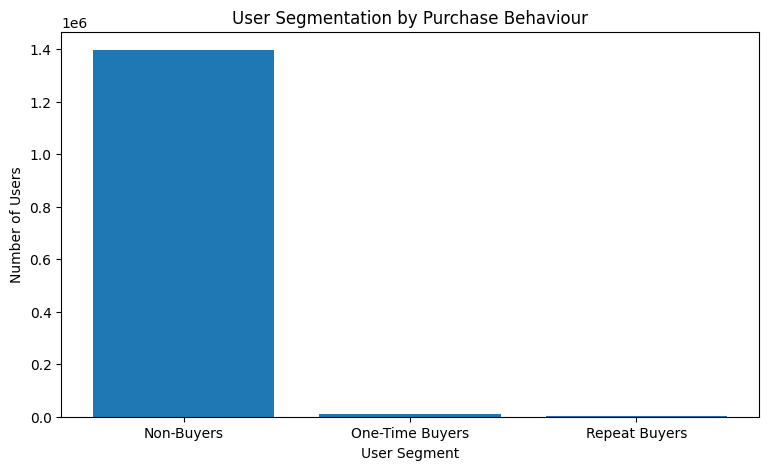

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    segmentation['User Segment'],
    segmentation['Users']
)

plt.title('User Segmentation by Purchase Behaviour')

plt.xlabel('User Segment')

plt.ylabel('Number of Users')

plt.show()

User Engagement Analysis

In [ ]:
user_engagement = (
    df.groupby('visitorid')
    .size()
    .reset_index(name='total_events')
)

user_engagement.head()

,visitorid,total_events
0,0,3
1,1,1
2,2,8
3,3,1
4,4,1


In [ ]:
def engagement_segment(events):
    if events <= 5:
        return 'Low Engagement'
    elif events <= 20:
        return 'Medium Engagement'
    else:
        return 'High Engagement'


user_engagement['engagement_segment'] = (
    user_engagement['total_events']
    .apply(engagement_segment)
)

user_engagement.head()

,visitorid,total_events,engagement_segment
0,0,3,Low Engagement
1,1,1,Low Engagement
2,2,8,Medium Engagement
3,3,1,Low Engagement
4,4,1,Low Engagement


In [ ]:
engagement_summary = (
    user_engagement['engagement_segment']
    .value_counts()
    .reset_index()
)

engagement_summary.columns = [
    'Engagement Segment',
    'Users'
]

engagement_summary

,Engagement Segment,Users
0,Low Engagement,1348927
1,Medium Engagement,52596
2,High Engagement,6057


In [ ]:
engagement_summary['Percentage'] = (
    engagement_summary['Users']
    / engagement_summary['Users'].sum()
    * 100
)

engagement_summary

,Engagement Segment,Users,Percentage
0,Low Engagement,1348927,95.833061
1,Medium Engagement,52596,3.736626
2,High Engagement,6057,0.430313


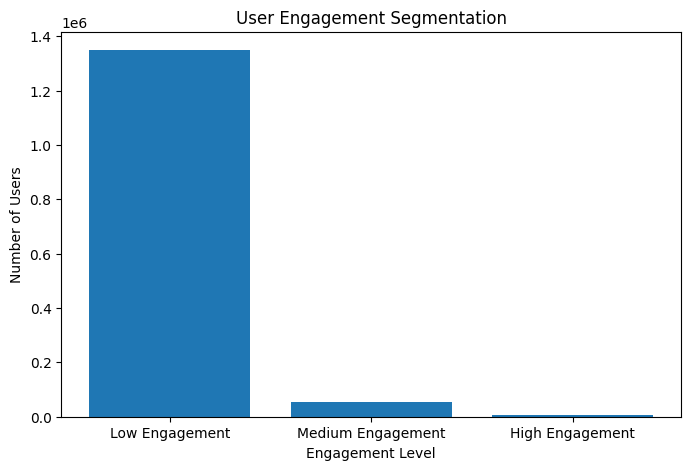

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    engagement_summary['Engagement Segment'],
    engagement_summary['Users']
)

plt.title('User Engagement Segmentation')

plt.xlabel('Engagement Level')

plt.ylabel('Number of Users')

plt.show()

Does Engagement Lead to Purchase?

In [ ]:
user_engagement['purchased'] = (
    user_engagement['visitorid']
    .isin(buyer_users)
)

In [ ]:
engagement_conversion = (
    user_engagement
    .groupby('engagement_segment')
    .agg(
        Users=('visitorid', 'count'),
        Buyers=('purchased', 'sum')
    )
    .reset_index()
)

engagement_conversion['Conversion Rate (%)'] = (
    engagement_conversion['Buyers']
    / engagement_conversion['Users']
    * 100
)

engagement_conversion

,engagement_segment,Users,Buyers,Conversion Rate (%)
0,High Engagement,6057,1525,25.177481
1,Low Engagement,1348927,5237,0.388235
2,Medium Engagement,52596,4957,9.424671


Repeat Purchase Analysis

In [ ]:
# Distribution of number of transactions per buyer

repeat_purchase_summary = (
    user_transactions['transaction_count']
    .value_counts()
    .sort_index()
    .reset_index()
)

repeat_purchase_summary.columns = [
    'Number of Purchases',
    'Number of Users'
]

repeat_purchase_summary.head(10)

,Number of Purchases,Number of Users
0,1,9143
1,2,1549
2,3,435
3,4,215
4,5,83
5,6,67
6,7,26
7,8,27
8,9,16
9,10,20


In [ ]:
total_buyers = len(buyer_users)

one_time_buyers = len(
    user_transactions[
        user_transactions['transaction_count'] == 1
    ]
)

repeat_buyers_count = len(
    user_transactions[
        user_transactions['transaction_count'] > 1
    ]
)

repeat_purchase_rate = (
    repeat_buyers_count / total_buyers
) * 100

print("Total Buyers:", total_buyers)
print("One-Time Buyers:", one_time_buyers)
print("Repeat Buyers:", repeat_buyers_count)
print(f"Repeat Purchase Rate: {repeat_purchase_rate:.2f}%")

Total Buyers: 11719
One-Time Buyers: 9143
Repeat Buyers: 2576
Repeat Purchase Rate: 21.98%


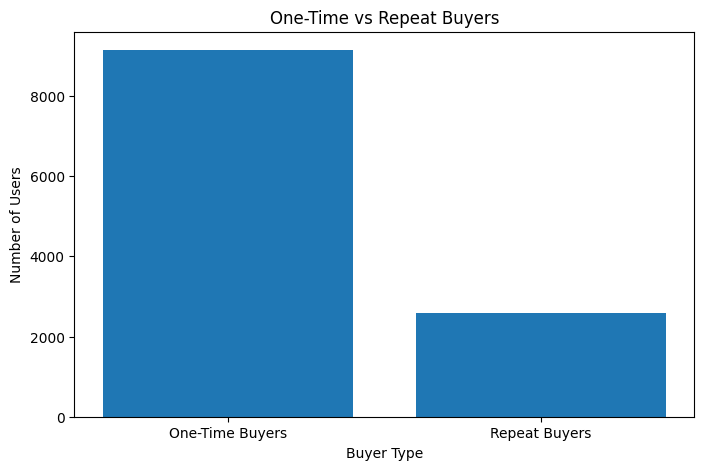

In [ ]:
purchase_behavior = pd.DataFrame({
    'Buyer Type': ['One-Time Buyers', 'Repeat Buyers'],
    'Users': [one_time_buyers, repeat_buyers_count]
})

plt.figure(figsize=(8, 5))

plt.bar(
    purchase_behavior['Buyer Type'],
    purchase_behavior['Users']
)

plt.title('One-Time vs Repeat Buyers')

plt.xlabel('Buyer Type')
plt.ylabel('Number of Users')

plt.show()

In [ ]:
transactions_df = df[
    df['event'] == 'transaction'
].copy()

transactions_df = transactions_df[
    ['visitorid', 'datetime', 'itemid', 'transactionid']
]

transactions_df = transactions_df.sort_values(
    ['visitorid', 'datetime']
)

transactions_df.head()

,visitorid,datetime,itemid,transactionid
848114,172,2015-08-15 01:29:01.230,465522,9725.0
850895,172,2015-08-15 01:29:01.686,10034,9725.0
814996,186,2015-08-12 16:34:57.040,49029,8726.0
1276395,264,2015-09-07 17:34:45.614,459835,8445.0
1283314,264,2015-09-07 17:34:45.708,161949,8445.0


In [ ]:
transactions_df['previous_purchase'] = (
    transactions_df
    .groupby('visitorid')['datetime']
    .shift(1)
)

transactions_df['days_since_previous_purchase'] = (
    (
        transactions_df['datetime']
        - transactions_df['previous_purchase']
    )
    .dt.total_seconds()
    / (60 * 60 * 24)
)

transactions_df.head(10)

,visitorid,datetime,itemid,transactionid,previous_purchase,days_since_previous_purchase
848114,172,2015-08-15 01:29:01.230,465522,9725.0,NaT,NaN
850895,172,2015-08-15 01:29:01.686,10034,9725.0,2015-08-15 01:29:01.230,0.000005
814996,186,2015-08-12 16:34:57.040,49029,8726.0,NaT,NaN
1276395,264,2015-09-07 17:34:45.614,459835,8445.0,NaT,NaN
1283314,264,2015-09-07 17:34:45.708,161949,8445.0,2015-09-07 17:34:45.614,0.000001
2687635,419,2015-07-29 05:03:12.695,19278,16455.0,NaT,NaN
273133,539,2015-06-16 05:39:38.673,94371,14778.0,NaT,NaN
960329,627,2015-08-20 20:48:36.892,414182,1332.0,NaT,NaN
782576,795,2015-08-10 22:02:07.846,207825,14460.0,NaT,NaN
912481,914,2015-08-18 00:50:47.831,382946,4718.0,NaT,NaN


In [ ]:
repeat_purchase_intervals = transactions_df[
    transactions_df['days_since_previous_purchase'].notna()
]

repeat_purchase_intervals[
    'days_since_previous_purchase'
].describe()

,days_since_previous_purchase
count,1.073800e+04
mean,1.168611e+00
std,6.462946e+00
min,0.000000e+00
25%,1.851852e-07
50%,5.711279e-03
75%,4.571137e-02
max,1.124770e+02


Time-Based User Behaviour Analysis

In [ ]:
daily_activity = (
    df.groupby('date')
    .size()
    .reset_index(name='total_events')
)

daily_activity.head()

,date,total_events
0,2015-05-03,13683
1,2015-05-04,19414
2,2015-05-05,23015
3,2015-05-06,23920
4,2015-05-07,23164


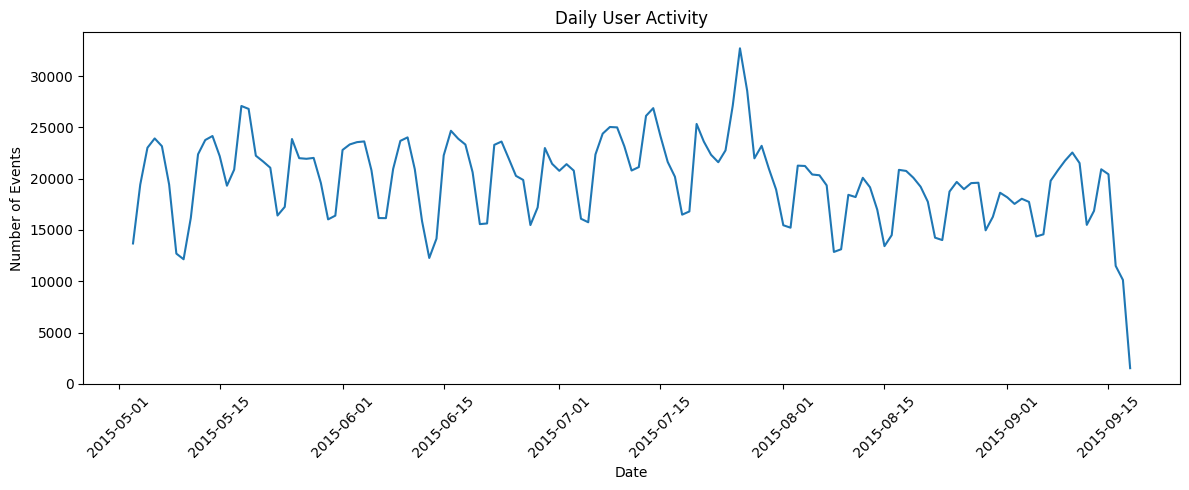

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_activity['date'],
    daily_activity['total_events']
)

plt.title('Daily User Activity')

plt.xlabel('Date')
plt.ylabel('Number of Events')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
daily_transactions = (
    df[df['event'] == 'transaction']
    .groupby('date')
    .size()
    .reset_index(name='transactions')
)

daily_transactions.head()

,date,transactions
0,2015-05-03,83
1,2015-05-04,154
2,2015-05-05,225
3,2015-05-06,258
4,2015-05-07,217


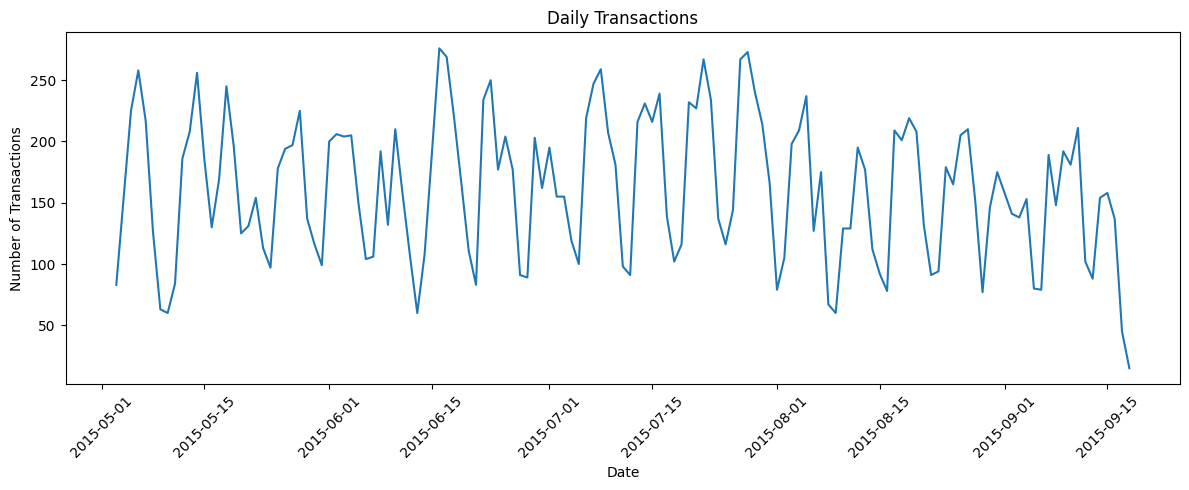

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_transactions['date'],
    daily_transactions['transactions']
)

plt.title('Daily Transactions')

plt.xlabel('Date')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
hourly_activity = (
    df.groupby('hour')
    .size()
    .reset_index(name='events')
)

hourly_activity

,hour,events
0,0,144303
1,1,140702
2,2,145879
3,3,150860
4,4,147184
5,5,119572
6,6,76972
7,7,43944
8,8,25309
9,9,17909


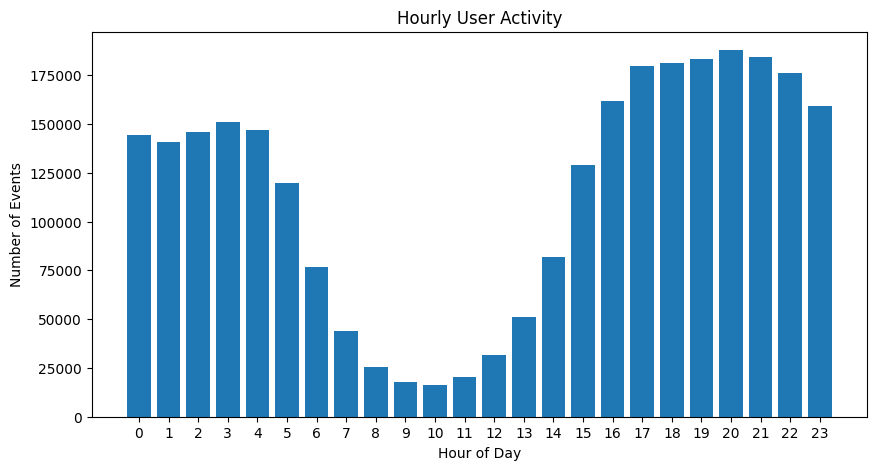

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    hourly_activity['hour'],
    hourly_activity['events']
)

plt.title('Hourly User Activity')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Events')

plt.xticks(range(24))

plt.show()

In [ ]:
hourly_transactions = (
    df[df['event'] == 'transaction']
    .groupby('hour')
    .size()
    .reset_index(name='transactions')
)

hourly_transactions

,hour,transactions
0,0,1119
1,1,1037
2,2,1012
3,3,836
4,4,747
5,5,747
6,6,477
7,7,278
8,8,106
9,9,70


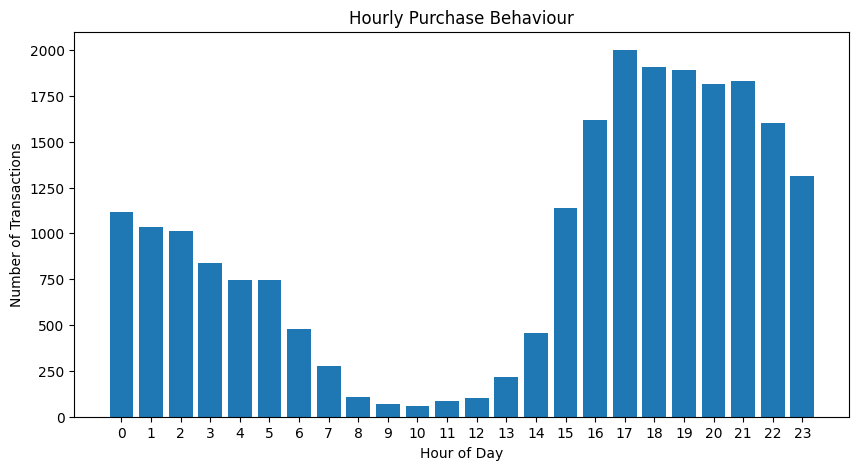

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    hourly_transactions['hour'],
    hourly_transactions['transactions']
)

plt.title('Hourly Purchase Behaviour')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')

plt.xticks(range(24))

plt.show()

Day-of-Week Analysis

In [ ]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [ ]:
day_activity = (
    df.groupby('day_of_week')
    .size()
    .reindex(day_order)
    .reset_index(name='events')
)

day_activity

,day_of_week,events
0,Monday,439813
1,Tuesday,447077
2,Wednesday,431114
3,Thursday,418761
4,Friday,379699
5,Saturday,305215
6,Sunday,334422


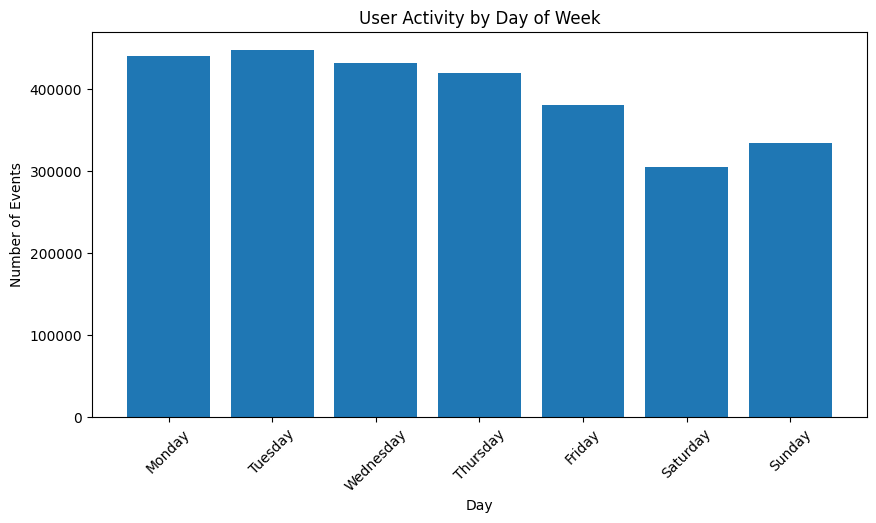

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    day_activity['day_of_week'],
    day_activity['events']
)

plt.title('User Activity by Day of Week')

plt.xlabel('Day')
plt.ylabel('Number of Events')

plt.xticks(rotation=45)

plt.show()

Product Performance & Conversion Analysis

In [ ]:
product_views = (
    df[df['event'] == 'view']
    .groupby('itemid')
    .size()
    .reset_index(name='views')
)

product_carts = (
    df[df['event'] == 'addtocart']
    .groupby('itemid')
    .size()
    .reset_index(name='add_to_cart')
)

product_transactions = (
    df[df['event'] == 'transaction']
    .groupby('itemid')
    .size()
    .reset_index(name='transactions')
)

In [ ]:
product_performance = (
    product_views
    .merge(product_carts, on='itemid', how='left')
    .merge(product_transactions, on='itemid', how='left')
)

product_performance = product_performance.fillna(0)

product_performance.head()

,itemid,views,add_to_cart,transactions
0,3,2,0.0,0.0
1,4,3,0.0,0.0
2,6,29,0.0,0.0
3,9,2,0.0,0.0
4,15,18,3.0,1.0


In [ ]:
product_performance['view_to_cart_rate'] = (
    product_performance['add_to_cart']
    / product_performance['views']
) * 100

product_performance['view_to_purchase_rate'] = (
    product_performance['transactions']
    / product_performance['views']
) * 100

In [ ]:
top_viewed_products = (
    product_performance
    .sort_values('views', ascending=False)
    .head(10)
)

top_viewed_products

,itemid,views,add_to_cart,transactions,view_to_cart_rate,view_to_purchase_rate
94618,187946,3410,2.0,0.0,0.058651,0.000000
232277,461686,2539,306.0,133.0,12.051989,5.238283
2717,5411,2325,9.0,0.0,0.387097,0.000000
186535,370653,1854,0.0,0.0,0.000000,0.000000
110421,219512,1740,48.0,12.0,2.758621,0.689655
150000,298009,1642,0.0,0.0,0.000000,0.000000
48965,96924,1633,0.0,0.0,0.000000,0.000000
155865,309778,1565,48.0,15.0,3.067093,0.958466
129372,257040,1531,89.0,27.0,5.813194,1.763553
193418,384302,1528,65.0,15.0,4.253927,0.981675


In [ ]:
top_purchased_products = (
    product_performance
    .sort_values('transactions', ascending=False)
    .head(10)
)

top_purchased_products

,itemid,views,add_to_cart,transactions,view_to_cart_rate,view_to_purchase_rate
232277,461686,2539,306.0,133.0,12.051989,5.238283
60457,119736,752,44.0,97.0,5.851064,12.898936
107577,213834,293,17.0,92.0,5.802048,31.399317
3974,7943,1346,97.0,46.0,7.206538,3.417533
157333,312728,947,162.0,46.0,17.106653,4.857445
224122,445351,939,89.0,45.0,9.478168,4.792332
24306,48030,986,95.0,41.0,9.634888,4.158215
125017,248455,575,52.0,38.0,9.043478,6.608696
211862,420960,796,60.0,38.0,7.537688,4.773869
8750,17478,631,72.0,37.0,11.410460,5.863708


Find High-Interest but Low-Conversion Products

In [ ]:
high_interest_products = product_performance[
    product_performance['views']
    >= product_performance['views'].median()
]

In [ ]:
potential_problem_products = (
    high_interest_products
    .sort_values('view_to_purchase_rate')
    .head(10)
)

potential_problem_products[
    [
        'itemid',
        'views',
        'add_to_cart',
        'transactions',
        'view_to_purchase_rate'
    ]
]

,itemid,views,add_to_cart,transactions,view_to_purchase_rate
152781,303587,20,0.0,0.0,0.0
152811,303643,3,0.0,0.0,0.0
152809,303638,8,0.0,0.0,0.0
152801,303623,8,0.0,0.0,0.0
152800,303620,5,0.0,0.0,0.0
152799,303619,72,0.0,0.0,0.0
152798,303617,73,3.0,0.0,0.0
152796,303614,19,1.0,0.0,0.0
152795,303613,4,0.0,0.0,0.0
152794,303612,10,0.0,0.0,0.0


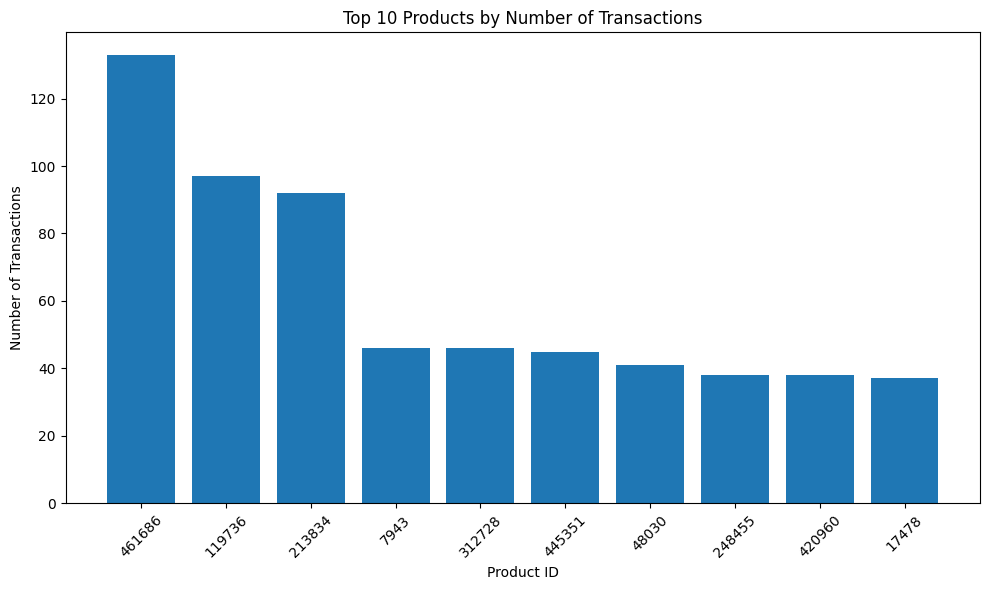

In [ ]:
top_10_purchased = (
    product_performance
    .sort_values('transactions', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_purchased['itemid'].astype(str),
    top_10_purchased['transactions']
)

plt.title('Top 10 Products by Number of Transactions')

plt.xlabel('Product ID')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Key Findings & Business Recommendations

In [ ]:
project_summary = {
    'Total Unique Users': df['visitorid'].nunique(),
    'Total Events': len(df),
    'View to Cart Conversion (%)': round(view_to_cart, 2),
    'Cart to Transaction Conversion (%)': round(cart_to_transaction, 2),
    'Overall Conversion (%)': round(overall_conversion, 2),
    'Cart Abandonment Rate (%)': round(cart_abandonment_rate, 2),
    'Repeat Purchase Rate (%)': round(repeat_purchase_rate, 2)
}

pd.DataFrame(
    project_summary.items(),
    columns=['Metric', 'Value']
)

,Metric,Value
0,Total Unique Users,1407580.00
1,Total Events,2756101.00
2,View to Cart Conversion (%),2.69
3,Cart to Transaction Conversion (%),31.07
4,Overall Conversion (%),0.83
5,Cart Abandonment Rate (%),71.96
6,Repeat Purchase Rate (%),21.98


Identify the Biggest Funnel Drop-Off

In [ ]:
dropoff_summary = pd.DataFrame({
    'Stage': [
        'View to Add to Cart',
        'Add to Cart to Transaction'
    ],
    'Drop-off Rate (%)': [
        view_dropoff,
        cart_dropoff
    ]
})

dropoff_summary

,Stage,Drop-off Rate (%)
0,View to Add to Cart,97.313590
1,Add to Cart to Transaction,68.933249


In [ ]:
biggest_dropoff = dropoff_summary.loc[
    dropoff_summary['Drop-off Rate (%)'].idxmax()
]

print("Biggest Drop-off Stage:")
print(biggest_dropoff)

Biggest Drop-off Stage:
Stage                View to Add to Cart
Drop-off Rate (%)               97.31359
Name: 0, dtype: object


Identify the Most Active Purchase Hours

In [ ]:
peak_purchase_hour = hourly_transactions.loc[
    hourly_transactions['transactions'].idxmax()
]

print("Peak Purchase Hour:")
print(peak_purchase_hour)

Peak Purchase Hour:
hour              17
transactions    2000
Name: 17, dtype: int64


In [ ]:
top_purchase_hours = (
    hourly_transactions
    .sort_values('transactions', ascending=False)
    .head(5)
)

top_purchase_hours

,hour,transactions
17,17,2000
18,18,1907
19,19,1891
21,21,1829
20,20,1817


Identify High-Value Products

In [ ]:
top_purchased_products[
    [
        'itemid',
        'views',
        'add_to_cart',
        'transactions',
        'view_to_purchase_rate'
    ]
]

,itemid,views,add_to_cart,transactions,view_to_purchase_rate
232277,461686,2539,306.0,133.0,5.238283
60457,119736,752,44.0,97.0,12.898936
107577,213834,293,17.0,92.0,31.399317
3974,7943,1346,97.0,46.0,3.417533
157333,312728,947,162.0,46.0,4.857445
224122,445351,939,89.0,45.0,4.792332
24306,48030,986,95.0,41.0,4.158215
125017,248455,575,52.0,38.0,6.608696
211862,420960,796,60.0,38.0,4.773869
8750,17478,631,72.0,37.0,5.863708


In [ ]:
potential_problem_products[
    [
        'itemid',
        'views',
        'add_to_cart',
        'transactions',
        'view_to_purchase_rate'
    ]
]

,itemid,views,add_to_cart,transactions,view_to_purchase_rate
152781,303587,20,0.0,0.0,0.0
152811,303643,3,0.0,0.0,0.0
152809,303638,8,0.0,0.0,0.0
152801,303623,8,0.0,0.0,0.0
152800,303620,5,0.0,0.0,0.0
152799,303619,72,0.0,0.0,0.0
152798,303617,73,3.0,0.0,0.0
152796,303614,19,1.0,0.0,0.0
152795,303613,4,0.0,0.0,0.0
152794,303612,10,0.0,0.0,0.0


**Key Findings & Business Recommendations:**
## Key Findings

### 1. Funnel Drop-off
The largest drop-off occurred between [Stage 1] and [Stage 2].
This stage should be investigated further to understand the barriers
preventing users from progressing through the purchase journey.

### 2. Cart Abandonment
The cart abandonment rate was [X]%, indicating a potential opportunity
to investigate checkout friction and barriers to completing purchases.

### 3. User Engagement
Users with [engagement segment] showed the highest conversion rate,
suggesting an association between user engagement and purchasing behaviour.

### 4. Repeat Purchase Behaviour
The repeat purchase rate was [X]%, indicating the proportion of customers
who returned to make additional purchases during the observed period.

### 5. Product Performance
Some products received high user interest but demonstrated relatively low
purchase conversion, making them potential candidates for further investigation.

## Business Recommendations

### 1. Investigate the Largest Funnel Drop-off
Conduct further analysis or user research to identify potential friction
at the stage with the highest drop-off.

### 2. Reduce Cart Abandonment
Investigate checkout experience, payment processes, delivery costs,
and other potential barriers to purchase completion.

### 3. Target Engagement Opportunities
Use behavioural insights to identify opportunities for personalised
recommendations or engagement strategies.

### 4. Investigate High-Interest, Low-Conversion Products
Review products with high views but low conversion to identify possible
issues related to pricing, product information, or availability.

### 5. Test Time-Based Engagement Strategies
Use identified high-activity periods as potential time windows for
testing promotions or engagement campaigns.

Cohort Retention Analysis

In [ ]:
df['week'] = df['datetime'].dt.to_period('W').apply(lambda r: r.start_time)

In [ ]:
user_first_week = (
    df.groupby('visitorid')['week']
    .min()
    .reset_index()
)

user_first_week.columns = [
    'visitorid',
    'cohort_week'
]

user_first_week.head()

,visitorid,cohort_week
0,0,2015-09-07
1,1,2015-08-10
2,2,2015-08-03
3,3,2015-07-27
4,4,2015-09-14


In [ ]:
cohort_data = df.merge(
    user_first_week,
    on='visitorid',
    how='left'
)

cohort_data.head()

,timestamp,visitorid,event,itemid,transactionid,datetime,date,hour,day_of_week,week,cohort_week
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,5,Tuesday,2015-06-01,2015-06-01
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,5,Tuesday,2015-06-01,2015-05-04
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,5,Tuesday,2015-06-01,2015-05-25
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,5,Tuesday,2015-06-01,2015-06-01
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,5,Tuesday,2015-06-01,2015-06-01


In [ ]:
cohort_data['cohort_index'] = (
    (
        cohort_data['week'] -
        cohort_data['cohort_week']
    ).dt.days // 7
)

In [ ]:
cohort_data[
    ['visitorid', 'week', 'cohort_week', 'cohort_index']
].head()

,visitorid,week,cohort_week,cohort_index
0,257597,2015-06-01,2015-06-01,0
1,992329,2015-06-01,2015-05-04,4
2,111016,2015-06-01,2015-05-25,1
3,483717,2015-06-01,2015-06-01,0
4,951259,2015-06-01,2015-06-01,0


In [ ]:
cohort_counts = (
    cohort_data
    .groupby(['cohort_week', 'cohort_index'])
    ['visitorid']
    .nunique()
    .reset_index()
)

cohort_counts.head()

,cohort_week,cohort_index,visitorid
0,2015-04-27,0,7865
1,2015-04-27,1,749
2,2015-04-27,2,322
3,2015-04-27,3,239
4,2015-04-27,4,166


In [ ]:
cohort_matrix = cohort_counts.pivot(
    index='cohort_week',
    columns='cohort_index',
    values='visitorid'
)

cohort_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
cohort_week,,,,,,,,,,,,,,,,,,,,,
2015-04-27,7865.0,749.0,322.0,239.0,166.0,146.0,127.0,120.0,96.0,87.0,...,87.0,82.0,75.0,60.0,57.0,52.0,66.0,46.0,48.0,24.0
2015-05-04,71389.0,3425.0,1988.0,1472.0,1170.0,916.0,910.0,808.0,720.0,719.0,...,645.0,551.0,461.0,437.0,451.0,433.0,403.0,437.0,210.0,NaN
2015-05-11,76662.0,3275.0,1592.0,1265.0,926.0,851.0,767.0,635.0,705.0,571.0,...,432.0,443.0,384.0,394.0,396.0,335.0,375.0,205.0,NaN,NaN
2015-05-18,78427.0,2731.0,1501.0,1000.0,881.0,786.0,658.0,658.0,599.0,580.0,...,423.0,385.0,385.0,367.0,335.0,428.0,197.0,NaN,NaN,NaN
2015-05-25,73231.0,2477.0,1178.0,897.0,762.0,648.0,625.0,558.0,559.0,395.0,...,365.0,361.0,368.0,319.0,350.0,171.0,NaN,NaN,NaN,NaN


In [ ]:
cohort_size = cohort_matrix.iloc[:, 0]

retention_matrix = (
    cohort_matrix
    .divide(cohort_size, axis=0)
    * 100
)

retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
cohort_week,,,,,,,,,,,,,,,,,,,,,
2015-04-27,100.0,9.523204,4.094088,3.038779,2.110617,1.856325,1.614749,1.525747,1.220598,1.106167,...,1.106167,1.042594,0.953592,0.762873,0.724730,0.661157,0.839161,0.584870,0.610299,0.305149
2015-05-04,100.0,4.797658,2.784743,2.061942,1.638908,1.283111,1.274706,1.131827,1.008559,1.007158,...,0.903501,0.771828,0.645758,0.612139,0.631750,0.606536,0.564513,0.612139,0.294163,NaN
2015-05-11,100.0,4.271999,2.076648,1.650100,1.207900,1.110068,1.000496,0.828311,0.919621,0.744828,...,0.563513,0.577861,0.500900,0.513944,0.516553,0.436983,0.489160,0.267408,NaN,NaN
2015-05-18,100.0,3.482219,1.913882,1.275071,1.123338,1.002206,0.838997,0.838997,0.763768,0.739541,...,0.539355,0.490902,0.490902,0.467951,0.427149,0.545730,0.251189,NaN,NaN,NaN
2015-05-25,100.0,3.382447,1.608608,1.224891,1.040543,0.884871,0.853464,0.761972,0.763338,0.539389,...,0.498423,0.492961,0.502519,0.435608,0.477940,0.233508,NaN,NaN,NaN,NaN


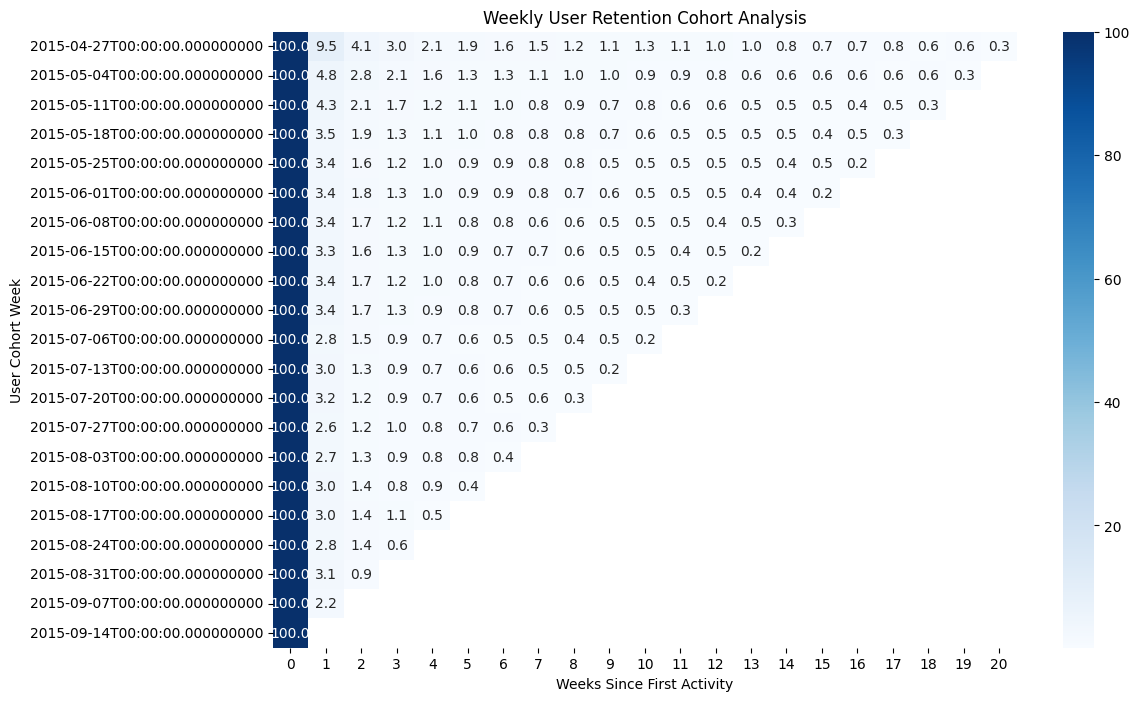

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Weekly User Retention Cohort Analysis')

plt.xlabel('Weeks Since First Activity')

plt.ylabel('User Cohort Week')

plt.show()